# Trademarkia Semantic Search System
## 20 Newsgroups | Soft Clustering | Semantic Cache | FastAPI



In [1]:
# Clean existing scientific stack
!pip uninstall -y numpy scipy scikit-learn pandas

# Install all dependencies together to avoid conflicts
!pip install --no-cache-dir \
numpy==1.26.4 \
scipy==1.11.4 \
scikit-learn==1.4.2 \
pandas==2.2.2 \
chromadb==0.4.24 \
sentence-transformers==2.7.0 \
fastapi==0.111.0 \
uvicorn[standard]==0.30.1 \
nest-asyncio \
pyngrok \
tqdm

# Verify installation
import numpy as np
print("NumPy version:", np.__version__)
print("numpy.char available:", hasattr(np, "char"))

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 125.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 308.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 311.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 199.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 261.9 MB/s eta 0:00:00
   ━━━━━━━

NumPy version: 2.0.2


ModuleNotFoundError: No module named 'numpy.char'

In [1]:
# Cell 2 - Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR     = '/content/drive/MyDrive/trademarkia_search'
EMBED_PATH   = os.path.join(SAVE_DIR, 'embeddings.npy')
CLUSTER_PATH = os.path.join(SAVE_DIR, 'cluster_dist.npy')
MODEL_PATH   = os.path.join(SAVE_DIR, 'clusterer.pkl')
CHROMA_PATH  = os.path.join(SAVE_DIR, 'chroma_db')
os.makedirs(SAVE_DIR, exist_ok=True)
print('Drive mounted:', SAVE_DIR)

Mounted at /content/drive
Drive mounted: /content/drive/MyDrive/trademarkia_search


In [2]:
# Cell 3 - Load and clean corpus
import re
import numpy as np
from sklearn.datasets import fetch_20newsgroups

def clean_text(text):
    text = re.sub(r'^>.*$', '', text, flags=re.MULTILINE)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+\.\S+', '', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r' {2,}', ' ', text)
    return text.strip()

print('Loading 20 Newsgroups dataset...')
raw = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes'),
    shuffle=True,
    random_state=42,
)
print('Raw documents:', len(raw.data))

texts, labels = [], []
for text, label in zip(raw.data, raw.target):
    cleaned = clean_text(text)
    if len(cleaned) >= 100:
        texts.append(cleaned)
        labels.append(int(label))

label_names = raw.target_names
print('After cleaning:', len(texts), 'documents')
print('Categories:', len(label_names))

Loading 20 Newsgroups dataset...
Raw documents: 18846
After cleaning: 17028 documents
Categories: 20


In [3]:
# Cell 4 - Embed documents
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

if os.path.exists(EMBED_PATH):
    print('Loading embeddings from Drive...')
    embeddings = np.load(EMBED_PATH)
else:
    print('Encoding documents...')
    embeddings = embed_model.encode(
        texts, batch_size=128, show_progress_bar=True,
        normalize_embeddings=True, convert_to_numpy=True,
    ).astype(np.float32)
    np.save(EMBED_PATH, embeddings)
    print('Saved to Drive')

print('Embeddings shape:', embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading embeddings from Drive...
Embeddings shape: (17028, 384)


In [4]:
# Cell 5 - Soft clustering with NMF
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

N_CLUSTERS = 15

if False:
    print('Loading clusterer from Drive...')
    with open(MODEL_PATH, 'rb') as f:
        saved = pickle.load(f)
    vectorizer   = saved['vectorizer']
    print("Vectorizer fitted:", hasattr(vectorizer, "idf_"))
    nmf          = saved['nmf']
    topic_words  = saved['topic_words']
    cluster_dist = np.load(CLUSTER_PATH)
else:
    print('Building TF-IDF matrix...')
    vectorizer = TfidfVectorizer(
        max_features=20000, stop_words='english',
        sublinear_tf=True, min_df=5, max_df=0.85,
    )
    X_tfidf = vectorizer.fit_transform(texts)
    print('Fitting NMF K=15...')
    nmf = NMF(n_components=N_CLUSTERS, init='nndsvda', random_state=42, max_iter=300, l1_ratio=0.1)
    W = nmf.fit_transform(X_tfidf)
    row_sums = W.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    cluster_dist = (W / row_sums).astype(np.float32)
    feature_names = vectorizer.get_feature_names_out()
    topic_words = []
    for topic_vec in nmf.components_:
        top_idx = topic_vec.argsort()[-15:][::-1]
        topic_words.append([feature_names[i] for i in top_idx])
    with open(MODEL_PATH, 'wb') as f:
        pickle.dump({'vectorizer': vectorizer, 'nmf': nmf, 'topic_words': topic_words}, f)
    np.save(CLUSTER_PATH, cluster_dist)
    print('Saved to Drive')

print('Cluster topics:')
print('='*60)
for i, words in enumerate(topic_words):
    print(f'Cluster {i:2d} |', ' | '.join(words[:6]))

Building TF-IDF matrix...
Fitting NMF K=15...
Saved to Drive
Cluster topics:
Cluster  0 | just | think | don | like | people | ve
Cluster  1 | thanks | mail | advance | hi | looking | email
Cluster  2 | game | team | games | year | hockey | play
Cluster  3 | program | file | window | files | use | code
Cluster  4 | card | video | monitor | bus | cards | vga
Cluster  5 | god | jesus | bible | believe | christian | christ
Cluster  6 | windows | dos | ms | os | file | run
Cluster  7 | n3jxp | chastity | intellect | skepticism | shameful | surrender
Cluster  8 | key | chip | clipper | encryption | keys | escrow
Cluster  9 | people | government | israel | state | children | war
Cluster 10 | drive | scsi | disk | hard | drives | ide
Cluster 11 | 00 | 10 | sale | 15 | 20 | 25
Cluster 12 | car | bike | new | cars | engine | used
Cluster 13 | know | don | let | want | like | sure
Cluster 14 | does | anybody | mean | work | doesn | information


In [5]:
print(hasattr(vectorizer, "idf_"))

True


In [12]:
import pickle

with open("clusterer.pkl", "wb") as f:
    pickle.dump((vectorizer, nmf), f)

print("clusterer.pkl saved successfully")

clusterer.pkl saved successfully


In [13]:
# Cell 6 - Insert into ChromaDB
import json
import chromadb

chroma_client = chromadb.PersistentClient(path=CHROMA_PATH)
collection = chroma_client.get_or_create_collection(
    name='newsgroups',
    metadata={'hnsw:space': 'cosine'},
)
existing = collection.count()
print('Documents in collection:', existing)

if existing == len(texts):
    print('Collection complete, skipping insertion')
else:
    if existing > 0:
        chroma_client.delete_collection('newsgroups')
        collection = chroma_client.get_or_create_collection(
            name='newsgroups', metadata={'hnsw:space': 'cosine'})
    BATCH_SIZE = 500
    n = len(texts)
    print('Inserting', n, 'documents...')
    for start in range(0, n, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n)
        batch_meta = []
        for i in range(start, end):
            dist     = cluster_dist[i]
            dominant = int(np.argmax(dist))
            batch_meta.append({
                'label': labels[i],
                'label_name': label_names[labels[i]],
                'dominant_cluster': dominant,
                'cluster_dist': json.dumps(dist.tolist()),
            })
        collection.add(
            ids=[str(i) for i in range(start, end)],
            documents=[texts[i][:512] for i in range(start, end)],
            embeddings=embeddings[start:end].tolist(),
            metadatas=batch_meta,
        )
        print('Inserted', end, '/', n)

print('Collection ready:', collection.count(), 'documents')

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Documents in collection: 17028
Collection complete, skipping insertion
Collection ready: 17028 documents


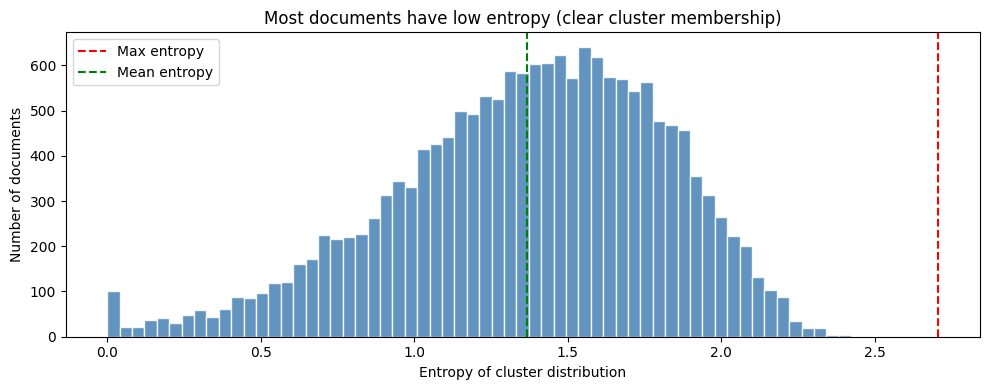

Mean entropy: 1.368

Most uncertain documents (boundary cases):
Label: sci.med
Cluster 12 (0.17) + Cluster 9 (0.12)
Text: Can anybody out there provide me with any advice concerning the
following two health problems:

First, I was recently di

Label: comp.os.ms-windows.misc
Cluster 3 (0.19) + Cluster 6 (0.13)
Text: PC Magazine, January 12, 1993 had a review of several personal finance
management programe, as did PC-Computing, January

Label: comp.windows.x
Cluster 13 (0.18) + Cluster 6 (0.17)
Text: : What has this got to do with comp.windows.x?
: 

I agree that this is a side track, but it is funny that I skip so man

Label: comp.sys.ibm.pc.hardware
Cluster 4 (0.18) + Cluster 14 (0.12)
Text: Thinking of buying from MidWest Micro of Ohio? Think *very* carefully.
Unless you are absolutely sure you won't have any

Label: sci.med
Cluster 0 (0.19) + Cluster 9 (0.18)
Text: GREAT post Martin. Very informative, well-balanced, and humanitarian
without neglecting the need for scientific rigor.



In [14]:
# Cell 7 - Cluster analysis
from scipy.stats import entropy as scipy_entropy
import matplotlib.pyplot as plt

entropies   = np.array([scipy_entropy(row + 1e-10) for row in cluster_dist])
max_entropy = np.log(N_CLUSTERS)

plt.figure(figsize=(10, 4))
plt.hist(entropies, bins=60, color='steelblue', alpha=0.85, edgecolor='white')
plt.axvline(max_entropy,      color='red',   linestyle='--', label='Max entropy')
plt.axvline(entropies.mean(), color='green', linestyle='--', label='Mean entropy')
plt.xlabel('Entropy of cluster distribution')
plt.ylabel('Number of documents')
plt.title('Most documents have low entropy (clear cluster membership)')
plt.legend()
plt.tight_layout()
plt.show()

print('Mean entropy:', round(entropies.mean(), 3))
print('\nMost uncertain documents (boundary cases):')
print('='*60)
for idx in entropies.argsort()[-5:][::-1]:
    top2 = cluster_dist[idx].argsort()[-2:][::-1]
    print('Label:', label_names[labels[idx]])
    print('Cluster', top2[0], '({:.2f})'.format(cluster_dist[idx][top2[0]]),
          '+ Cluster', top2[1], '({:.2f})'.format(cluster_dist[idx][top2[1]]))
    print('Text:', texts[idx][:120])
    print()

In [15]:
# Cell 8 - Semantic cache
import threading
import time
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple

@dataclass
class CacheEntry:
    query_text: str
    query_vec:  Any
    result:     Any
    dominant_cluster: int
    timestamp: float = field(default_factory=time.time)

class SemanticCache:
    def __init__(self, threshold=0.75):
        self.threshold   = threshold
        self._store      = {}
        self._lock       = threading.RLock()
        self._hit_count  = 0
        self._miss_count = 0

    def lookup(self, query_vec, dominant_cluster):
        with self._lock:
            bucket = self._store.get(dominant_cluster, [])
            if not bucket:
                self._miss_count += 1
                return None
            stored_vecs  = np.stack([e.query_vec for e in bucket])
            similarities = stored_vecs @ query_vec
            best_idx     = int(np.argmax(similarities))
            best_sim     = float(similarities[best_idx])
            if best_sim >= self.threshold:
                self._hit_count += 1
                return bucket[best_idx], best_sim
            self._miss_count += 1
            return None

    def store(self, query_text, query_vec, result, dominant_cluster):
        entry = CacheEntry(query_text, query_vec.copy(), result, dominant_cluster)
        with self._lock:
            self._store.setdefault(dominant_cluster, []).append(entry)

    def flush(self):
        with self._lock:
            self._store.clear()
            self._hit_count  = 0
            self._miss_count = 0

    def stats(self):
        with self._lock:
            total = self._hit_count + self._miss_count
            return {
                'total_entries': sum(len(b) for b in self._store.values()),
                'hit_count':     self._hit_count,
                'miss_count':    self._miss_count,
                'hit_rate':      round(self._hit_count / total, 4) if total else 0.0,
            }

    def __len__(self):
        return sum(len(b) for b in self._store.values())

cache = SemanticCache(threshold=0.75)
print('SemanticCache ready, threshold:', cache.threshold)

SemanticCache ready, threshold: 0.75


In [16]:
# Cell 9 - Helper functions

def get_dominant_cluster(text):
    X       = vectorizer.transform([text])
    W       = nmf.transform(X)
    row_sum = W.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    dist = (W / row_sum)[0].astype(np.float32)
    return int(np.argmax(dist)), dist

def format_results(results):
    docs      = results['documents'][0]
    metas     = results['metadatas'][0]
    distances = results['distances'][0]
    if not docs:
        return 'No results found.'
    lines = []
    for i, (doc, meta, dist) in enumerate(zip(docs, metas, distances), 1):
        sim = round(1 - dist, 3)
        lines.append(f'[{i}] ({meta["label_name"]}, similarity={sim})\n    {doc[:200]}...')
    return '\n\n'.join(lines)

print('Helper functions ready')

Helper functions ready


In [10]:
# Cell 10 - Define FastAPI app
import nest_asyncio
nest_asyncio.apply()

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

app = FastAPI(title='Trademarkia Semantic Search')

class QueryRequest(BaseModel):
    query: str

@app.post('/query')
async def query_endpoint(req: QueryRequest):
    if not req.query.strip():
        raise HTTPException(400, 'Query cannot be empty.')

    q_vec            = embed_model.encode(req.query, normalize_embeddings=True)
    dominant_cluster, dist = get_dominant_cluster(req.query)
    top2             = dist.argsort()[-2:][::-1]

    hit = None
    for cluster_id in top2:
        hit = cache.lookup(q_vec, int(cluster_id))
        if hit:
            break

    if hit:
        entry, sim = hit
        return {
            'query':            req.query,
            'cache_hit':        True,
            'matched_query':    entry.query_text,
            'similarity_score': round(sim, 4),
            'result':           entry.result,
            'dominant_cluster': dominant_cluster,
        }

    results = collection.query(
        query_embeddings=[q_vec.tolist()], n_results=5,
        include=['documents', 'metadatas', 'distances'],
    )
    result_text = format_results(results)

    for cluster_id in top2:
        cache.store(req.query, q_vec, result_text, int(cluster_id))

    return {
        'query':            req.query,
        'cache_hit':        False,
        'matched_query':    None,
        'similarity_score': None,
        'result':           result_text,
        'dominant_cluster': dominant_cluster,
    }

@app.get('/cache/stats')
async def cache_stats():
    return cache.stats()

@app.delete('/cache')
async def flush_cache():
    cache.flush()
    return {'message': 'Cache flushed.'}

@app.get('/health')
async def health():
    return {
        'status':        'ok',
        'docs_indexed':  collection.count(),
        'cache_entries': len(cache),
        'threshold':     cache.threshold,
        'n_clusters':    N_CLUSTERS,
    }

print('FastAPI app ready')
print('Endpoints: POST /query | GET /cache/stats | DELETE /cache | GET /health')

FastAPI app ready
Endpoints: POST /query | GET /cache/stats | DELETE /cache | GET /health


In [17]:
import os
print(os.listdir())

['.config', 'clusterer.pkl', 'drive', 'sample_data']


In [18]:
from google.colab import files
files.download("clusterer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>